# Import Libraries

In [10]:
import os
import zipfile
import random
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [9]:
!pip install torch pandas numpy scikit-learn tqdm requests

# Import Data & Pre-Processing

In [3]:
DATA_DIR = "data"
ML100K_DIR = os.path.join(DATA_DIR, "ml-100k")
ZIP_PATH = os.path.join(DATA_DIR, "ml-100k.zip")

os.makedirs(DATA_DIR, exist_ok = True)

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

if not os.path.exists(ML100K_DIR):
    print("Downloading MovieLens 100K...")
    r = requests.get(url)
    r.raise_for_status()
    with open(ZIP_PATH, "wb") as f:
        f.write(r.content)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

print("Dataset ready:", ML100K_DIR)

Dataset ready: data\ml-100k


In [4]:
ratings_path = os.path.join(ML100K_DIR, "u.data")

ratings = pd.read_csv(ratings_path, sep = "\t", names = ["user_id", "item_id", "rating", "timestamp"])
ratings.head(), ratings.shape

(   user_id  item_id  rating  timestamp
 0      196      242       3  881250949
 1      186      302       3  891717742
 2       22      377       1  878887116
 3      244       51       2  880606923
 4      166      346       1  886397596,
 (100000, 4))

In [5]:
# keep positive interactions --> recomendation is binary now

positive = ratings[ratings["rating"] >= 4].copy()

positive["user_id"] = positive["user_id"].astype(int) - 1
positive["item_id"] = positive["item_id"].astype(int) - 1

num_users = positive["user_id"].nunique()
num_items = positive["item_id"].nunique()

num_users, num_items, positive.shape

(942, 1447, (55375, 4))

In [6]:
# train/test split --> 1 positive per user for test

positive = positive.sort_values(["user_id", "timestamp"])

train_rows = []
test_rows = []

for user, group in positive.groupby("user_id"):
    if len(group) < 2:
        continue

    test = group.iloc[-1]
    train = group.iloc[:-1]

    test_rows.append(test)
    train_rows.append(train)

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.DataFrame(test_rows).reset_index(drop=True)

train_df.shape, test_df.shape

((54433, 4), (942, 4))

In [7]:
# re-index users/items after filtering -- PyTorch embeddings need indices

users = sorted(train_df["user_id"].unique())
items = sorted(train_df["item_id"].unique())

user_map = {u: idx for idx, u in enumerate(users)}
item_map = {i: idx for idx, i in enumerate(items)}

train_df = train_df[
    train_df["user_id"].isin(user_map) & train_df["item_id"].isin(item_map)
].copy()

test_df = test_df[
    test_df["user_id"].isin(user_map) & test_df["item_id"].isin(item_map)
].copy()

train_df["user"] = train_df["user_id"].map(user_map)
train_df["item"] = train_df["item_id"].map(item_map)

test_df["user"] = test_df["user_id"].map(user_map)
test_df["item"] = test_df["item_id"].map(item_map)

num_users = len(user_map)
num_items = len(item_map)

num_users, num_items, train_df.shape, test_df.shape

(942, 1432, (54433, 6), (927, 6))

In [8]:
# build train interaction sets

train_user_pos = train_df.groupby("user")["item"].apply(set).to_dict()
all_items = set(range(num_items))

train_pairs = list(zip(train_df["user"].values, train_df["item"].values))
len(train_pairs)

54433

# Models

## Baseline: LightGCN model

In [15]:
# create undirected bipartite graph - sparse normalized adjacency for LightGCN

def build_lightgcn_adj(num_users, num_items, interactions):
    num_nodes = num_users + num_items

    rows = []
    cols = []

    for u, i in interactions:
        item_node = num_users + i
        rows.extend([u, item_node])
        cols.extend([item_node, u])

    edge_index = torch.tensor([rows, cols], dtype=torch.long)

    deg = torch.bincount(edge_index[0], minlength=num_nodes).float()
    deg_inv_sqrt = torch.pow(deg, -0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    values = deg_inv_sqrt[edge_index[0]] * deg_inv_sqrt[edge_index[1]]

    adj = torch.sparse_coo_tensor(
        edge_index,
        values,
        size=(num_nodes, num_nodes)
    ).coalesce()

    return adj

adj = build_lightgcn_adj(num_users, num_items, train_pairs).to(device)
adj

C:\Users\mxenaki\AppData\Local\Temp\ipykernel_23708\4107863497.py:22: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  adj = torch.sparse_coo_tensor(


tensor(indices=tensor([[   0,    0,    0,  ..., 2373, 2373, 2373],
                       [ 942,  944,  947,  ...,  780,  868,  878]]),
       values=tensor([0.0044, 0.0139, 0.0203,  ..., 0.0833, 0.0479, 0.0426]),
       size=(2374, 2374), nnz=108866, layout=torch.sparse_coo)

In [16]:
# LightGCN model

class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def forward(self, adj):
        user_emb = self.user_embedding.weight
        item_emb = self.item_embedding.weight

        all_emb = torch.cat([user_emb, item_emb], dim=0)
        embeddings = [all_emb]

        for _ in range(self.num_layers):
            all_emb = torch.sparse.mm(adj, all_emb)
            embeddings.append(all_emb)

        final_emb = torch.mean(torch.stack(embeddings, dim=0), dim=0)

        final_user_emb = final_emb[:self.num_users]
        final_item_emb = final_emb[self.num_users:]

        return final_user_emb, final_item_emb

    def predict(self, users, items, adj):
        user_emb, item_emb = self.forward(adj)
        return (user_emb[users] * item_emb[items]).sum(dim=1)

In [17]:
# BPR loss & negative sampling

def sample_batch(train_pairs, train_user_pos, num_items, batch_size):
    batch = random.sample(train_pairs, batch_size)

    users = []
    pos_items = []
    neg_items = []

    for u, pos in batch:
        neg = random.randint(0, num_items - 1)
        while neg in train_user_pos[u]:
            neg = random.randint(0, num_items - 1)

        users.append(u)
        pos_items.append(pos)
        neg_items.append(neg)

    return (
        torch.tensor(users, dtype=torch.long, device=device),
        torch.tensor(pos_items, dtype=torch.long, device=device),
        torch.tensor(neg_items, dtype=torch.long, device=device)
    )


def bpr_loss(user_emb, pos_emb, neg_emb):
    pos_scores = (user_emb * pos_emb).sum(dim=1)
    neg_scores = (user_emb * neg_emb).sum(dim=1)
    return -torch.mean(F.logsigmoid(pos_scores - neg_scores))

In [18]:
# training function

def train_lightgcn(
    model,
    adj,
    train_pairs,
    train_user_pos,
    num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for _ in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_final, item_final = model(adj)

            u_emb = user_final[users]
            pos_emb = item_final[pos_items]
            neg_emb = item_final[neg_items]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            loss = loss + reg_weight * reg_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

    return history

In [19]:
# evaluation metrics

def evaluate_model(model, adj, train_user_pos, test_df, num_items, k=10, num_negatives=99):
    model.eval()

    with torch.no_grad():
        user_emb, item_emb = model(adj)

    recalls = []
    hits = []
    ndcgs = []

    users_eval = test_df["user"].values
    pos_items_eval = test_df["item"].values

    for u, true_item in zip(users_eval, pos_items_eval):
        negatives = list(all_items - train_user_pos.get(u, set()) - {true_item})

        if len(negatives) > num_negatives:
            sampled_negatives = random.sample(negatives, num_negatives)
        else:
            sampled_negatives = negatives

        candidates = sampled_negatives + [true_item]

        users_tensor = torch.tensor([u] * len(candidates), dtype=torch.long, device=device)
        items_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        with torch.no_grad():
            scores = (user_emb[users_tensor] * item_emb[items_tensor]).sum(dim=1)

        topk_indices = torch.topk(scores, min(k, len(candidates))).indices.cpu().numpy()
        topk_items = [candidates[idx] for idx in topk_indices]

        hit = int(true_item in topk_items)
        hits.append(hit)
        recalls.append(hit)

        if hit:
            rank = topk_items.index(true_item)
            ndcg = 1 / np.log2(rank + 2)
        else:
            ndcg = 0.0

        ndcgs.append(ndcg)

    return {
        f"HR@{k}": float(np.mean(hits)),
        f"Recall@{k}": float(np.mean(recalls)),
        f"NDCG@{k}": float(np.mean(ndcgs)),
    }

In [20]:
# run baseline

model = LightGCN(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=64,
    num_layers=3
).to(device)

history = train_lightgcn(
    model=model,
    adj=adj,
    train_pairs=train_pairs,
    train_user_pos=train_user_pos,
    num_items=num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4
)

results = evaluate_model(
    model=model,
    adj=adj,
    train_user_pos=train_user_pos,
    test_df=test_df,
    num_items=num_items,
    k=10,
    num_negatives=99
)

results

Epoch 001 | Loss: 0.6845
Epoch 010 | Loss: 0.3190
Epoch 020 | Loss: 0.2813
Epoch 030 | Loss: 0.2412
Epoch 040 | Loss: 0.2203
Epoch 050 | Loss: 0.2087


{'HR@10': 0.5685005393743258,
 'Recall@10': 0.5685005393743258,
 'NDCG@10': 0.31151753609799954}

## BPR-MF baseline

In [21]:
# BPR-MF model

class BPRMF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def forward(self):
        return self.user_embedding.weight, self.item_embedding.weight

    def predict(self, users, items):
        user_emb = self.user_embedding(users)
        item_emb = self.item_embedding(items)
        return (user_emb * item_emb).sum(dim=1)

In [22]:
# train BPR-MF

def train_bprmf(
    model,
    train_pairs,
    train_user_pos,
    num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for _ in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs,
                train_user_pos,
                num_items,
                batch_size
            )

            user_emb, item_emb = model()

            u_emb = user_emb[users]
            pos_emb = item_emb[pos_items]
            neg_emb = item_emb[neg_items]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            loss = loss + reg_weight * reg_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

    return history

In [23]:
# evaluate BPR-MF

def evaluate_bprmf(model, train_user_pos, test_df, num_items, k=10, num_negatives=99):
    model.eval()

    with torch.no_grad():
        user_emb, item_emb = model()

    hits = []
    recalls = []
    ndcgs = []

    users_eval = test_df["user"].values
    pos_items_eval = test_df["item"].values

    for u, true_item in zip(users_eval, pos_items_eval):
        negatives = list(all_items - train_user_pos.get(u, set()) - {true_item})

        if len(negatives) > num_negatives:
            sampled_negatives = random.sample(negatives, num_negatives)
        else:
            sampled_negatives = negatives

        candidates = sampled_negatives + [true_item]

        users_tensor = torch.tensor([u] * len(candidates), dtype=torch.long, device=device)
        items_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        with torch.no_grad():
            scores = (user_emb[users_tensor] * item_emb[items_tensor]).sum(dim=1)

        topk_indices = torch.topk(scores, min(k, len(candidates))).indices.cpu().numpy()
        topk_items = [candidates[idx] for idx in topk_indices]

        hit = int(true_item in topk_items)
        hits.append(hit)
        recalls.append(hit)

        if hit:
            rank = topk_items.index(true_item)
            ndcg = 1 / np.log2(rank + 2)
        else:
            ndcg = 0.0

        ndcgs.append(ndcg)

    return {
        f"HR@{k}": float(np.mean(hits)),
        f"Recall@{k}": float(np.mean(recalls)),
        f"NDCG@{k}": float(np.mean(ndcgs)),
    }

In [24]:
# run BPR-MF baseline

bprmf_model = BPRMF(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=64
).to(device)

bprmf_history = train_bprmf(
    model=bprmf_model,
    train_pairs=train_pairs,
    train_user_pos=train_user_pos,
    num_items=num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4
)

bprmf_results = evaluate_bprmf(
    model=bprmf_model,
    train_user_pos=train_user_pos,
    test_df=test_df,
    num_items=num_items,
    k=10,
    num_negatives=99
)

bprmf_results

Epoch 001 | Loss: 0.6931
Epoch 010 | Loss: 0.3735
Epoch 020 | Loss: 0.2335
Epoch 030 | Loss: 0.1742
Epoch 040 | Loss: 0.1392
Epoch 050 | Loss: 0.1120


{'HR@10': 0.5846817691477886,
 'Recall@10': 0.5846817691477886,
 'NDCG@10': 0.33198441080998753}

## SSL Variant 1 - Edge Dropout

In [30]:
# edge dropout augmentation

def edge_dropout(train_pairs, drop_rate=0.2):
    kept_pairs = []

    for pair in train_pairs:
        if random.random() > drop_rate:
            kept_pairs.append(pair)

    # Safety: avoid empty graph
    if len(kept_pairs) == 0:
        kept_pairs = train_pairs

    return kept_pairs

In [31]:
# Contrastive loss

def contrastive_loss(z1, z2, temperature=0.2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)

    loss_1 = F.cross_entropy(logits, labels)
    loss_2 = F.cross_entropy(logits.T, labels)

    return (loss_1 + loss_2) / 2

In [32]:
# training function with Edge Dropout SSL

def train_lightgcn_edge_ssl(
    model,
    train_pairs,
    train_user_pos,
    num_users,
    num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4,
    ssl_weight=0.1,
    drop_rate=0.2,
    temperature=0.2
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        # Create two graph views once per epoch
        pairs_view1 = edge_dropout(train_pairs, drop_rate=drop_rate)
        pairs_view2 = edge_dropout(train_pairs, drop_rate=drop_rate)

        adj_view1 = build_lightgcn_adj(num_users, num_items, pairs_view1).to(device)
        adj_view2 = build_lightgcn_adj(num_users, num_items, pairs_view2).to(device)

        # Full train graph for recommendation loss
        adj_full = build_lightgcn_adj(num_users, num_items, train_pairs).to(device)

        for _ in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_full, item_full = model(adj_full)

            u_emb = user_full[users]
            pos_emb = item_full[pos_items]
            neg_emb = item_full[neg_items]

            rec_loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            user_v1, item_v1 = model(adj_view1)
            user_v2, item_v2 = model(adj_view2)

            ssl_user_loss = contrastive_loss(user_v1[users], user_v2[users], temperature)
            ssl_item_loss = contrastive_loss(item_v1[pos_items], item_v2[pos_items], temperature)
            ssl_loss = ssl_user_loss + ssl_item_loss

            if epoch == 1 and _ == 0:
                print("REC LOSS:", rec_loss.item())
                print("SSL LOSS:", ssl_loss.item())
            
            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

    return history

In [18]:
# run Edge Dropout SSL

edge_ssl_model = LightGCN(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=64,
    num_layers=3
).to(device)

edge_ssl_history = train_lightgcn_edge_ssl(
    model=edge_ssl_model,
    train_pairs=train_pairs,
    train_user_pos=train_user_pos,
    num_users=num_users,
    num_items=num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4,
    ssl_weight=0.01,
    drop_rate=0.2,
    temperature=0.2
)

edge_ssl_results = evaluate_model(
    model=edge_ssl_model,
    adj=adj,
    train_user_pos=train_user_pos,
    test_df=test_df,
    num_items=num_items,
    k=10,
    num_negatives=99
)

edge_ssl_results

REC LOSS: 0.6925603151321411
SSL LOSS: 5.003002643585205
Epoch 001 | Loss: 0.7413
Epoch 010 | Loss: 0.5665
Epoch 020 | Loss: 0.3152
Epoch 030 | Loss: 0.2866
Epoch 040 | Loss: 0.2681
Epoch 050 | Loss: 0.2558


{'HR@10': 0.6170442286947141,
 'Recall@10': 0.6170442286947141,
 'NDCG@10': 0.3529441814735612}

### Sanity Checks

In [19]:
len(train_pairs)

54433

In [20]:
drop_rate = 0.2

pairs_view1 = edge_dropout(train_pairs, drop_rate)

print(len(train_pairs))
print(len(pairs_view1))

54433
43540


### Run SSL-Edge Drop-out experiments

In [22]:
configs = [
    {"ssl_weight": 0.005, "drop_rate": 0.1},
    {"ssl_weight": 0.005, "drop_rate": 0.2},
    {"ssl_weight": 0.005, "drop_rate": 0.3},

    {"ssl_weight": 0.01,  "drop_rate": 0.1},
    {"ssl_weight": 0.01,  "drop_rate": 0.2},
    {"ssl_weight": 0.01,  "drop_rate": 0.3},

    {"ssl_weight": 0.05,  "drop_rate": 0.1},
    {"ssl_weight": 0.05,  "drop_rate": 0.2},
    {"ssl_weight": 0.05,  "drop_rate": 0.3},
]

In [23]:
results = []

for cfg in configs:

    print("\n========================")
    print(cfg)
    print("========================")

    model = LightGCN(
        num_users=num_users,
        num_items=num_items,
        embedding_dim=64,
        num_layers=3
    ).to(device)

    train_lightgcn_edge_ssl(
        model=model,
        train_pairs=train_pairs,
        train_user_pos=train_user_pos,
        num_users=num_users,
        num_items=num_items,
        epochs=50,
        batch_size=1024,
        lr=1e-3,
        reg_weight=1e-4,
        ssl_weight=cfg["ssl_weight"],
        drop_rate=cfg["drop_rate"],
        temperature=0.2
    )

    metrics = evaluate_model(
        model=model,
        adj=adj,
        train_user_pos=train_user_pos,
        test_df=test_df,
        num_items=num_items,
        k=10,
        num_negatives=99
    )

    results.append({
        "ssl_weight": cfg["ssl_weight"],
        "drop_rate": cfg["drop_rate"],
        "HR@10": metrics["HR@10"],
        "Recall@10": metrics["Recall@10"],
        "NDCG@10": metrics["NDCG@10"]
    })


{'ssl_weight': 0.005, 'drop_rate': 0.1}
REC LOSS: 0.6923457980155945
SSL LOSS: 4.949285984039307
Epoch 001 | Loss: 0.7167
Epoch 010 | Loss: 0.3250
Epoch 020 | Loss: 0.2720
Epoch 030 | Loss: 0.2586
Epoch 040 | Loss: 0.2351
Epoch 050 | Loss: 0.2266

{'ssl_weight': 0.005, 'drop_rate': 0.2}
REC LOSS: 0.69239741563797
SSL LOSS: 4.9815778732299805
Epoch 001 | Loss: 0.7168
Epoch 010 | Loss: 0.3270
Epoch 020 | Loss: 0.2745
Epoch 030 | Loss: 0.2548
Epoch 040 | Loss: 0.2405
Epoch 050 | Loss: 0.2240

{'ssl_weight': 0.005, 'drop_rate': 0.3}
REC LOSS: 0.692542552947998
SSL LOSS: 5.01091194152832
Epoch 001 | Loss: 0.7170
Epoch 010 | Loss: 0.3256
Epoch 020 | Loss: 0.2681
Epoch 030 | Loss: 0.2576
Epoch 040 | Loss: 0.2403
Epoch 050 | Loss: 0.2286

{'ssl_weight': 0.01, 'drop_rate': 0.1}
REC LOSS: 0.6926085352897644
SSL LOSS: 4.944421768188477
Epoch 001 | Loss: 0.7411
Epoch 010 | Loss: 0.5772
Epoch 020 | Loss: 0.3136
Epoch 030 | Loss: 0.2807
Epoch 040 | Loss: 0.2649
Epoch 050 | Loss: 0.2524

{'ssl_weigh

In [24]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "NDCG@10",
    ascending=False
)

,ssl_weight,drop_rate,HR@10,Recall@10,NDCG@10
7,0.050,0.2,0.623517,0.623517,0.358764
8,0.050,0.3,0.618123,0.618123,0.353027
6,0.050,0.1,0.612729,0.612729,0.352784
3,0.010,0.1,0.614887,0.614887,0.351141
4,0.010,0.2,0.624595,0.624595,0.349737
0,0.005,0.1,0.613808,0.613808,0.343922
1,0.005,0.2,0.605178,0.605178,0.343131
2,0.005,0.3,0.623517,0.623517,0.342960
5,0.010,0.3,0.617044,0.617044,0.340881


## SSL Variant 2 - Embedding Noise / SimGCL

In [33]:
# add noise to embeddings

def add_embedding_noise(embeddings, eps=0.1):
    noise = torch.rand_like(embeddings)
    noise = F.normalize(noise, dim=1)
    return embeddings + eps * torch.sign(embeddings) * noise

In [34]:
# training function with Embedding Noise SSL

def train_lightgcn_noise_ssl(
    model,
    adj,
    train_pairs,
    train_user_pos,
    num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4,
    ssl_weight=0.05,
    noise_eps=0.1,
    temperature=0.2
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for step in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_full, item_full = model(adj)

            u_emb = user_full[users]
            pos_emb = item_full[pos_items]
            neg_emb = item_full[neg_items]

            rec_loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            user_view1 = add_embedding_noise(user_full, eps=noise_eps)
            user_view2 = add_embedding_noise(user_full, eps=noise_eps)

            item_view1 = add_embedding_noise(item_full, eps=noise_eps)
            item_view2 = add_embedding_noise(item_full, eps=noise_eps)

            ssl_user_loss = contrastive_loss(
                user_view1[users],
                user_view2[users],
                temperature
            )

            ssl_item_loss = contrastive_loss(
                item_view1[pos_items],
                item_view2[pos_items],
                temperature
            )

            ssl_loss = ssl_user_loss + ssl_item_loss

            if epoch == 1 and step == 0:
                print("REC LOSS:", rec_loss.item())
                print("SSL LOSS:", ssl_loss.item())

            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

    return history

### Single SimGCL sanity run

In [31]:
# single SimGCL sanity run

noise_ssl_model = LightGCN(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=64,
    num_layers=3
).to(device)

noise_ssl_history = train_lightgcn_noise_ssl(
    model=noise_ssl_model,
    adj=adj,
    train_pairs=train_pairs,
    train_user_pos=train_user_pos,
    num_items=num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4,
    ssl_weight=0.05,
    noise_eps=0.1,
    temperature=0.2
)

noise_ssl_results = evaluate_model(
    model=noise_ssl_model,
    adj=adj,
    train_user_pos=train_user_pos,
    test_df=test_df,
    num_items=num_items,
    k=10,
    num_negatives=99
)

noise_ssl_results

REC LOSS: 0.6924700140953064
SSL LOSS: 5.197940826416016
Epoch 001 | Loss: 0.9459
Epoch 010 | Loss: 0.9204
Epoch 020 | Loss: 0.8131
Epoch 030 | Loss: 0.5890
Epoch 040 | Loss: 0.5200
Epoch 050 | Loss: 0.4784


{'HR@10': 0.6105717367853291,
 'Recall@10': 0.6105717367853291,
 'NDCG@10': 0.34955705385673996}

### Run experiments

In [34]:
# SimGCL grid configs

simgcl_configs = [
    {"ssl_weight": 0.005, "noise_eps": 0.05},
    {"ssl_weight": 0.005, "noise_eps": 0.10},
    {"ssl_weight": 0.005, "noise_eps": 0.20},

    {"ssl_weight": 0.01,  "noise_eps": 0.05},
    {"ssl_weight": 0.01,  "noise_eps": 0.10},
    {"ssl_weight": 0.01,  "noise_eps": 0.20},

    {"ssl_weight": 0.05,  "noise_eps": 0.05},
    {"ssl_weight": 0.05,  "noise_eps": 0.10},
    {"ssl_weight": 0.05,  "noise_eps": 0.20},
]

In [35]:
# run SimGCL experiments

noise_results = []

for cfg in simgcl_configs:
    print("\n========================")
    print(cfg)
    print("========================")

    model = LightGCN(
        num_users=num_users,
        num_items=num_items,
        embedding_dim=64,
        num_layers=3
    ).to(device)

    train_lightgcn_noise_ssl(
        model=model,
        adj=adj,
        train_pairs=train_pairs,
        train_user_pos=train_user_pos,
        num_items=num_items,
        epochs=50,
        batch_size=1024,
        lr=1e-3,
        reg_weight=1e-4,
        ssl_weight=cfg["ssl_weight"],
        noise_eps=cfg["noise_eps"],
        temperature=0.2
    )

    metrics = evaluate_model(
        model=model,
        adj=adj,
        train_user_pos=train_user_pos,
        test_df=test_df,
        num_items=num_items,
        k=10,
        num_negatives=99
    )

    noise_results.append({
        "method": "Embedding Noise SSL",
        "ssl_weight": cfg["ssl_weight"],
        "noise_eps": cfg["noise_eps"],
        "HR@10": metrics["HR@10"],
        "Recall@10": metrics["Recall@10"],
        "NDCG@10": metrics["NDCG@10"]
    })

noise_results_df = pd.DataFrame(noise_results)
noise_results_df.sort_values("NDCG@10", ascending=False)


{'ssl_weight': 0.005, 'noise_eps': 0.05}
REC LOSS: 0.6924214959144592
SSL LOSS: 5.014768600463867
Epoch 001 | Loss: 0.7170
Epoch 010 | Loss: 0.3273
Epoch 020 | Loss: 0.2763
Epoch 030 | Loss: 0.2565
Epoch 040 | Loss: 0.2407
Epoch 050 | Loss: 0.2288

{'ssl_weight': 0.005, 'noise_eps': 0.1}
REC LOSS: 0.6924870014190674
SSL LOSS: 5.14901065826416
Epoch 001 | Loss: 0.7177
Epoch 010 | Loss: 0.3293
Epoch 020 | Loss: 0.2757
Epoch 030 | Loss: 0.2585
Epoch 040 | Loss: 0.2411
Epoch 050 | Loss: 0.2328

{'ssl_weight': 0.005, 'noise_eps': 0.2}
REC LOSS: 0.6925162076950073
SSL LOSS: 5.476502895355225
Epoch 001 | Loss: 0.7193
Epoch 010 | Loss: 0.3382
Epoch 020 | Loss: 0.2797
Epoch 030 | Loss: 0.2631
Epoch 040 | Loss: 0.2537
Epoch 050 | Loss: 0.2414

{'ssl_weight': 0.01, 'noise_eps': 0.05}
REC LOSS: 0.6926540732383728
SSL LOSS: 5.035998344421387
Epoch 001 | Loss: 0.7417
Epoch 010 | Loss: 0.4553
Epoch 020 | Loss: 0.3158
Epoch 030 | Loss: 0.2868
Epoch 040 | Loss: 0.2650
Epoch 050 | Loss: 0.2532

{'ssl_w

,method,ssl_weight,noise_eps,HR@10,Recall@10,NDCG@10
3,Embedding Noise SSL,0.010,0.05,0.622438,0.622438,0.349805
5,Embedding Noise SSL,0.010,0.20,0.612729,0.612729,0.349664
8,Embedding Noise SSL,0.050,0.20,0.590076,0.590076,0.348926
7,Embedding Noise SSL,0.050,0.10,0.609493,0.609493,0.348847
6,Embedding Noise SSL,0.050,0.05,0.601942,0.601942,0.348305
4,Embedding Noise SSL,0.010,0.10,0.617044,0.617044,0.344341
0,Embedding Noise SSL,0.005,0.05,0.599784,0.599784,0.338984
2,Embedding Noise SSL,0.005,0.20,0.604099,0.604099,0.337471
1,Embedding Noise SSL,0.005,0.10,0.593312,0.593312,0.332764


## SSL Variant 3 - Proposed Method: Popularity-Aware Edge Dropout

In [35]:
# item popularity

from collections import Counter

item_popularity = Counter([i for _, i in train_pairs])

pop_values = np.array([item_popularity.get(i, 0) for i in range(num_items)])
pop_min = pop_values.min()
pop_max = pop_values.max()

pop_min, pop_max

(np.int64(1), np.int64(496))

In [36]:
# Popularity-Aware Edge Dropout

def popularity_aware_edge_dropout(
    train_pairs,
    item_popularity,
    base_drop_rate=0.2,
    alpha=1.0
):
    pop_values = np.array([item_popularity.get(i, 0) for _, i in train_pairs], dtype=np.float32)

    pop_min = pop_values.min()
    pop_max = pop_values.max()

    if pop_max == pop_min:
        normalized_pop = np.zeros_like(pop_values)
    else:
        normalized_pop = (pop_values - pop_min) / (pop_max - pop_min)

    kept_pairs = []

    for pair, pop_score in zip(train_pairs, normalized_pop):
        drop_prob = base_drop_rate * (1.0 + alpha * pop_score)
        drop_prob = min(drop_prob, 0.8)

        if random.random() > drop_prob:
            kept_pairs.append(pair)

    if len(kept_pairs) == 0:
        kept_pairs = train_pairs

    return kept_pairs

In [37]:
# train Popularity-Aware Edge SSL

def train_lightgcn_pop_edge_ssl(
    model,
    train_pairs,
    train_user_pos,
    item_popularity,
    num_users,
    num_items,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4,
    ssl_weight=0.05,
    base_drop_rate=0.2,
    alpha=1.0,
    temperature=0.2
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        pairs_view1 = popularity_aware_edge_dropout(
            train_pairs,
            item_popularity,
            base_drop_rate=base_drop_rate,
            alpha=alpha
        )

        pairs_view2 = popularity_aware_edge_dropout(
            train_pairs,
            item_popularity,
            base_drop_rate=base_drop_rate,
            alpha=alpha
        )

        adj_view1 = build_lightgcn_adj(num_users, num_items, pairs_view1).to(device)
        adj_view2 = build_lightgcn_adj(num_users, num_items, pairs_view2).to(device)
        adj_full = build_lightgcn_adj(num_users, num_items, train_pairs).to(device)

        for step in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs,
                train_user_pos,
                num_items,
                batch_size
            )

            user_full, item_full = model(adj_full)

            u_emb = user_full[users]
            pos_emb = item_full[pos_items]
            neg_emb = item_full[neg_items]

            rec_loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            user_v1, item_v1 = model(adj_view1)
            user_v2, item_v2 = model(adj_view2)

            ssl_user_loss = contrastive_loss(
                user_v1[users],
                user_v2[users],
                temperature
            )

            ssl_item_loss = contrastive_loss(
                item_v1[pos_items],
                item_v2[pos_items],
                temperature
            )

            ssl_loss = ssl_user_loss + ssl_item_loss

            if epoch == 1 and step == 0:
                print("REC LOSS:", rec_loss.item())
                print("SSL LOSS:", ssl_loss.item())
                print("View1 edges:", len(pairs_view1))
                print("View2 edges:", len(pairs_view2))

            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

    return history

In [38]:
# Popularity-Aware configs

pop_edge_configs = [
    {"ssl_weight": 0.05, "base_drop_rate": 0.1, "alpha": 0.5},
    {"ssl_weight": 0.05, "base_drop_rate": 0.2, "alpha": 0.5},
    {"ssl_weight": 0.05, "base_drop_rate": 0.2, "alpha": 1.0},
    {"ssl_weight": 0.05, "base_drop_rate": 0.2, "alpha": 1.5},
]

In [39]:
# run Popularity-Aware Edge SSL

pop_edge_results = []

for cfg in pop_edge_configs:
    print("\n========================")
    print("Running config:", cfg)
    print("========================")

    model = LightGCN(
        num_users=num_users,
        num_items=num_items,
        embedding_dim=64,
        num_layers=3
    ).to(device)

    train_lightgcn_pop_edge_ssl(
        model=model,
        train_pairs=train_pairs,
        train_user_pos=train_user_pos,
        item_popularity=item_popularity,
        num_users=num_users,
        num_items=num_items,
        epochs=50,
        batch_size=1024,
        lr=1e-3,
        reg_weight=1e-4,
        ssl_weight=cfg["ssl_weight"],
        base_drop_rate=cfg["base_drop_rate"],
        alpha=cfg["alpha"],
        temperature=0.2
    )

    metrics = evaluate_model(
        model=model,
        adj=adj,
        train_user_pos=train_user_pos,
        test_df=test_df,
        num_items=num_items,
        k=10,
        num_negatives=99
    )

    row = {
        "method": "Popularity-Aware Edge SSL",
        "ssl_weight": cfg["ssl_weight"],
        "base_drop_rate": cfg["base_drop_rate"],
        "alpha": cfg["alpha"],
        "HR@10": metrics["HR@10"],
        "Recall@10": metrics["Recall@10"],
        "NDCG@10": metrics["NDCG@10"]
    }

    pop_edge_results.append(row)
    print("Result:", row)

pop_edge_results_df = pd.DataFrame(pop_edge_results)

pop_edge_results_df.sort_values("NDCG@10", ascending=False)


Running config: {'ssl_weight': 0.05, 'base_drop_rate': 0.1, 'alpha': 0.5}
REC LOSS: 0.6924064755439758
SSL LOSS: 4.939140319824219
View1 edges: 48253
View2 edges: 48269
Epoch 001 | Loss: 0.9356
Epoch 010 | Loss: 0.9289
Epoch 020 | Loss: 0.8969
Epoch 030 | Loss: 0.7907
Epoch 040 | Loss: 0.5825
Epoch 050 | Loss: 0.5091
Result: {'method': 'Popularity-Aware Edge SSL', 'ssl_weight': 0.05, 'base_drop_rate': 0.1, 'alpha': 0.5, 'HR@10': 0.6040992448759439, 'Recall@10': 0.6040992448759439, 'NDCG@10': 0.35378096551310717}

Running config: {'ssl_weight': 0.05, 'base_drop_rate': 0.2, 'alpha': 0.5}
REC LOSS: 0.6923720836639404
SSL LOSS: 4.978421211242676
View1 edges: 41980
View2 edges: 42367
Epoch 001 | Loss: 0.9369
Epoch 010 | Loss: 0.9297
Epoch 020 | Loss: 0.8962
Epoch 030 | Loss: 0.7765
Epoch 040 | Loss: 0.5680
Epoch 050 | Loss: 0.5035
Result: {'method': 'Popularity-Aware Edge SSL', 'ssl_weight': 0.05, 'base_drop_rate': 0.2, 'alpha': 0.5, 'HR@10': 0.61596548004315, 'Recall@10': 0.61596548004315

,method,ssl_weight,base_drop_rate,alpha,HR@10,Recall@10,NDCG@10
3,Popularity-Aware Edge SSL,0.05,0.2,1.5,0.611650,0.611650,0.359291
0,Popularity-Aware Edge SSL,0.05,0.1,0.5,0.604099,0.604099,0.353781
1,Popularity-Aware Edge SSL,0.05,0.2,0.5,0.615965,0.615965,0.349174
2,Popularity-Aware Edge SSL,0.05,0.2,1.0,0.604099,0.604099,0.345094


## SSL Variant 4 - Proposed Method: Adaptive Noise Dense/Sparse-Aware

In [40]:
# compute user/item degrees

user_degrees = np.zeros(num_users, dtype=np.float32)
item_degrees = np.zeros(num_items, dtype=np.float32)

for u, i in train_pairs:
    user_degrees[u] += 1
    item_degrees[i] += 1

user_degrees_tensor = torch.tensor(user_degrees, dtype=torch.float32, device=device)
item_degrees_tensor = torch.tensor(item_degrees, dtype=torch.float32, device=device)

user_degrees.min(), user_degrees.max(), item_degrees.min(), item_degrees.max()

(np.float32(2.0), np.float32(377.0), np.float32(1.0), np.float32(496.0))

In [41]:
# degree-adaptive noise

def degree_adaptive_noise(embeddings, degrees, base_eps=0.1, mode="dense"):
    degrees = degrees.float()

    min_deg = degrees.min()
    max_deg = degrees.max()

    if max_deg == min_deg:
        scale = torch.ones_like(degrees)
    else:
        norm_deg = (degrees - min_deg) / (max_deg - min_deg)

        if mode == "dense":
            scale = norm_deg
        elif mode == "sparse":
            scale = 1.0 - norm_deg
        else:
            raise ValueError("mode must be 'dense' or 'sparse'")

    scale = scale.unsqueeze(1)

    noise = torch.rand_like(embeddings)
    noise = F.normalize(noise, dim=1)

    return embeddings + base_eps * scale * torch.sign(embeddings) * noise

In [42]:
# train adaptive noise SSL

def train_lightgcn_adaptive_noise_ssl(
    model,
    adj,
    train_pairs,
    train_user_pos,
    num_items,
    user_degrees_tensor,
    item_degrees_tensor,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4,
    ssl_weight=0.01,
    base_eps=0.1,
    mode="dense",
    temperature=0.2
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for step in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_full, item_full = model(adj)

            u_emb = user_full[users]
            pos_emb = item_full[pos_items]
            neg_emb = item_full[neg_items]

            rec_loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            user_view1 = degree_adaptive_noise(
                user_full, user_degrees_tensor, base_eps=base_eps, mode=mode
            )
            user_view2 = degree_adaptive_noise(
                user_full, user_degrees_tensor, base_eps=base_eps, mode=mode
            )

            item_view1 = degree_adaptive_noise(
                item_full, item_degrees_tensor, base_eps=base_eps, mode=mode
            )
            item_view2 = degree_adaptive_noise(
                item_full, item_degrees_tensor, base_eps=base_eps, mode=mode
            )

            ssl_user_loss = contrastive_loss(user_view1[users], user_view2[users], temperature)
            ssl_item_loss = contrastive_loss(item_view1[pos_items], item_view2[pos_items], temperature)
            ssl_loss = ssl_user_loss + ssl_item_loss

            if epoch == 1 and step == 0:
                print("Mode:", mode)
                print("REC LOSS:", rec_loss.item())
                print("SSL LOSS:", ssl_loss.item())

            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

    return history

In [43]:
# run adaptive noise configs

adaptive_noise_configs = [
    {"mode": "dense",  "ssl_weight": 0.01, "base_eps": 0.05},
    {"mode": "dense",  "ssl_weight": 0.01, "base_eps": 0.10},
    {"mode": "dense",  "ssl_weight": 0.01, "base_eps": 0.20},

    {"mode": "sparse", "ssl_weight": 0.01, "base_eps": 0.05},
    {"mode": "sparse", "ssl_weight": 0.01, "base_eps": 0.10},
    {"mode": "sparse", "ssl_weight": 0.01, "base_eps": 0.20},
]

adaptive_noise_results = []

for cfg in adaptive_noise_configs:
    print("\n========================")
    print("Running config:", cfg)
    print("========================")

    model = LightGCN(
        num_users=num_users,
        num_items=num_items,
        embedding_dim=64,
        num_layers=3
    ).to(device)

    train_lightgcn_adaptive_noise_ssl(
        model=model,
        adj=adj,
        train_pairs=train_pairs,
        train_user_pos=train_user_pos,
        num_items=num_items,
        user_degrees_tensor=user_degrees_tensor,
        item_degrees_tensor=item_degrees_tensor,
        epochs=50,
        batch_size=1024,
        lr=1e-3,
        reg_weight=1e-4,
        ssl_weight=cfg["ssl_weight"],
        base_eps=cfg["base_eps"],
        mode=cfg["mode"],
        temperature=0.2
    )

    metrics = evaluate_model(
        model=model,
        adj=adj,
        train_user_pos=train_user_pos,
        test_df=test_df,
        num_items=num_items,
        k=10,
        num_negatives=99
    )

    row = {
        "method": f"Adaptive Noise ({cfg['mode']})",
        "mode": cfg["mode"],
        "ssl_weight": cfg["ssl_weight"],
        "base_eps": cfg["base_eps"],
        "HR@10": metrics["HR@10"],
        "Recall@10": metrics["Recall@10"],
        "NDCG@10": metrics["NDCG@10"]
    }

    adaptive_noise_results.append(row)
    print("Result:", row)

adaptive_noise_results_df = pd.DataFrame(adaptive_noise_results)
adaptive_noise_results_df.sort_values("NDCG@10", ascending=False)


Running config: {'mode': 'dense', 'ssl_weight': 0.01, 'base_eps': 0.05}
Mode: dense
REC LOSS: 0.692649781703949
SSL LOSS: 4.938057899475098
Epoch 001 | Loss: 0.7410
Epoch 010 | Loss: 0.5612
Epoch 020 | Loss: 0.3148
Epoch 030 | Loss: 0.2879
Epoch 040 | Loss: 0.2682
Epoch 050 | Loss: 0.2550
Result: {'method': 'Adaptive Noise (dense)', 'mode': 'dense', 'ssl_weight': 0.01, 'base_eps': 0.05, 'HR@10': 0.6138079827400216, 'Recall@10': 0.6138079827400216, 'NDCG@10': 0.3499300357088292}

Running config: {'mode': 'dense', 'ssl_weight': 0.01, 'base_eps': 0.1}
Mode: dense
REC LOSS: 0.6921897530555725
SSL LOSS: 4.948491096496582
Epoch 001 | Loss: 0.7412
Epoch 010 | Loss: 0.5097
Epoch 020 | Loss: 0.3142
Epoch 030 | Loss: 0.2870
Epoch 040 | Loss: 0.2682
Epoch 050 | Loss: 0.2562
Result: {'method': 'Adaptive Noise (dense)', 'mode': 'dense', 'ssl_weight': 0.01, 'base_eps': 0.1, 'HR@10': 0.6170442286947141, 'Recall@10': 0.6170442286947141, 'NDCG@10': 0.3512627213342039}

Running config: {'mode': 'dense'

,method,mode,ssl_weight,base_eps,HR@10,Recall@10,NDCG@10
2,Adaptive Noise (dense),dense,0.01,0.20,0.618123,0.618123,0.352922
1,Adaptive Noise (dense),dense,0.01,0.10,0.617044,0.617044,0.351263
3,Adaptive Noise (sparse),sparse,0.01,0.05,0.615965,0.615965,0.350457
0,Adaptive Noise (dense),dense,0.01,0.05,0.613808,0.613808,0.349930
5,Adaptive Noise (sparse),sparse,0.01,0.20,0.601942,0.601942,0.345799
4,Adaptive Noise (sparse),sparse,0.01,0.10,0.606257,0.606257,0.340655


## SSL Variant 5 - Proposed Combined Method: Popularity-aware Edge dropout & best Adaptive Noise Variant

In [44]:
# train combined Adaptive SSL

def train_lightgcn_combined_adaptive_ssl(
    model,
    train_pairs,
    train_user_pos,
    item_popularity,
    num_users,
    num_items,
    user_degrees_tensor,
    item_degrees_tensor,
    epochs=50,
    batch_size=1024,
    lr=1e-3,
    reg_weight=1e-4,
    ssl_weight=0.05,
    base_drop_rate=0.2,
    alpha=1.0,
    base_eps=0.05,
    noise_mode="dense",
    temperature=0.2
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        # Popularity-aware graph views
        pairs_view1 = popularity_aware_edge_dropout(
            train_pairs,
            item_popularity,
            base_drop_rate=base_drop_rate,
            alpha=alpha
        )

        pairs_view2 = popularity_aware_edge_dropout(
            train_pairs,
            item_popularity,
            base_drop_rate=base_drop_rate,
            alpha=alpha
        )

        adj_view1 = build_lightgcn_adj(num_users, num_items, pairs_view1).to(device)
        adj_view2 = build_lightgcn_adj(num_users, num_items, pairs_view2).to(device)
        adj_full = build_lightgcn_adj(num_users, num_items, train_pairs).to(device)

        for step in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs,
                train_user_pos,
                num_items,
                batch_size
            )

            # Recommendation loss on full graph
            user_full, item_full = model(adj_full)

            u_emb = user_full[users]
            pos_emb = item_full[pos_items]
            neg_emb = item_full[neg_items]

            rec_loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            # SSL embeddings from popularity-aware graph views
            user_v1, item_v1 = model(adj_view1)
            user_v2, item_v2 = model(adj_view2)

            # Add degree-adaptive noise on top of graph-view embeddings
            user_v1 = degree_adaptive_noise(
                user_v1,
                user_degrees_tensor,
                base_eps=base_eps,
                mode=noise_mode
            )

            user_v2 = degree_adaptive_noise(
                user_v2,
                user_degrees_tensor,
                base_eps=base_eps,
                mode=noise_mode
            )

            item_v1 = degree_adaptive_noise(
                item_v1,
                item_degrees_tensor,
                base_eps=base_eps,
                mode=noise_mode
            )

            item_v2 = degree_adaptive_noise(
                item_v2,
                item_degrees_tensor,
                base_eps=base_eps,
                mode=noise_mode
            )

            ssl_user_loss = contrastive_loss(
                user_v1[users],
                user_v2[users],
                temperature
            )

            ssl_item_loss = contrastive_loss(
                item_v1[pos_items],
                item_v2[pos_items],
                temperature
            )

            ssl_loss = ssl_user_loss + ssl_item_loss

            if epoch == 1 and step == 0:
                print("REC LOSS:", rec_loss.item())
                print("SSL LOSS:", ssl_loss.item())
                print("View1 edges:", len(pairs_view1))
                print("View2 edges:", len(pairs_view2))
                print("Noise mode:", noise_mode)

            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        history.append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f}")

    return history

In [45]:
# combined adaptive configs

combined_configs = [
    {
        "ssl_weight": 0.05,
        "base_drop_rate": 0.2,
        "alpha": 0.5,
        "base_eps": 0.05,
        "noise_mode": "dense"
    },
    {
        "ssl_weight": 0.05,
        "base_drop_rate": 0.2,
        "alpha": 1.0,
        "base_eps": 0.05,
        "noise_mode": "dense"
    },
    {
        "ssl_weight": 0.05,
        "base_drop_rate": 0.2,
        "alpha": 0.5,
        "base_eps": 0.05,
        "noise_mode": "sparse"
    },
    {
        "ssl_weight": 0.05,
        "base_drop_rate": 0.2,
        "alpha": 1.0,
        "base_eps": 0.05,
        "noise_mode": "sparse"
    },
]

In [46]:
# run combined adaptive SSL

combined_results = []

for cfg in combined_configs:
    print("\n========================")
    print("Running config:", cfg)
    print("========================")

    model = LightGCN(
        num_users=num_users,
        num_items=num_items,
        embedding_dim=64,
        num_layers=3
    ).to(device)

    train_lightgcn_combined_adaptive_ssl(
        model=model,
        train_pairs=train_pairs,
        train_user_pos=train_user_pos,
        item_popularity=item_popularity,
        num_users=num_users,
        num_items=num_items,
        user_degrees_tensor=user_degrees_tensor,
        item_degrees_tensor=item_degrees_tensor,
        epochs=50,
        batch_size=1024,
        lr=1e-3,
        reg_weight=1e-4,
        ssl_weight=cfg["ssl_weight"],
        base_drop_rate=cfg["base_drop_rate"],
        alpha=cfg["alpha"],
        base_eps=cfg["base_eps"],
        noise_mode=cfg["noise_mode"],
        temperature=0.2
    )

    metrics = evaluate_model(
        model=model,
        adj=adj,
        train_user_pos=train_user_pos,
        test_df=test_df,
        num_items=num_items,
        k=10,
        num_negatives=99
    )

    row = {
        "method": "Combined Adaptive SSL",
        "ssl_weight": cfg["ssl_weight"],
        "base_drop_rate": cfg["base_drop_rate"],
        "alpha": cfg["alpha"],
        "base_eps": cfg["base_eps"],
        "noise_mode": cfg["noise_mode"],
        "HR@10": metrics["HR@10"],
        "Recall@10": metrics["Recall@10"],
        "NDCG@10": metrics["NDCG@10"]
    }

    combined_results.append(row)
    print("Result:", row)

combined_results_df = pd.DataFrame(combined_results)

combined_results_df.sort_values("NDCG@10", ascending=False)


Running config: {'ssl_weight': 0.05, 'base_drop_rate': 0.2, 'alpha': 0.5, 'base_eps': 0.05, 'noise_mode': 'dense'}
REC LOSS: 0.6925652623176575
SSL LOSS: 4.955230236053467
View1 edges: 42275
View2 edges: 42210
Noise mode: dense
Epoch 001 | Loss: 0.9371
Epoch 010 | Loss: 0.9286
Epoch 020 | Loss: 0.8861
Epoch 030 | Loss: 0.7363
Epoch 040 | Loss: 0.5529
Epoch 050 | Loss: 0.4986
Result: {'method': 'Combined Adaptive SSL', 'ssl_weight': 0.05, 'base_drop_rate': 0.2, 'alpha': 0.5, 'base_eps': 0.05, 'noise_mode': 'dense', 'HR@10': 0.6170442286947141, 'Recall@10': 0.6170442286947141, 'NDCG@10': 0.35563762648323916}

Running config: {'ssl_weight': 0.05, 'base_drop_rate': 0.2, 'alpha': 1.0, 'base_eps': 0.05, 'noise_mode': 'dense'}
REC LOSS: 0.6924003958702087
SSL LOSS: 5.004748344421387
View1 edges: 40716
View2 edges: 40771
Noise mode: dense
Epoch 001 | Loss: 0.9373
Epoch 010 | Loss: 0.9291
Epoch 020 | Loss: 0.8862
Epoch 030 | Loss: 0.7273
Epoch 040 | Loss: 0.5505
Epoch 050 | Loss: 0.4947
Result

,method,ssl_weight,base_drop_rate,alpha,base_eps,noise_mode,HR@10,Recall@10,NDCG@10
0,Combined Adaptive SSL,0.05,0.2,0.5,0.05,dense,0.617044,0.617044,0.355638
3,Combined Adaptive SSL,0.05,0.2,1.0,0.05,sparse,0.611650,0.611650,0.349851
2,Combined Adaptive SSL,0.05,0.2,0.5,0.05,sparse,0.598706,0.598706,0.349048
1,Combined Adaptive SSL,0.05,0.2,1.0,0.05,dense,0.608414,0.608414,0.348337


## Sparsity Experiments

In [47]:
METHODS = [
    "BPR-MF",
    "LightGCN",
    "Edge SSL",
    "SimGCL",
    "Adaptive Noise Dense"
]

In [48]:
# create Sparse Train Set

def create_sparse_train_pairs(train_pairs, keep_ratio=1.0, seed=42):
    rng = np.random.default_rng(seed)

    n_keep = int(len(train_pairs) * keep_ratio)

    idx = rng.choice(
        len(train_pairs),
        size=n_keep,
        replace=False
    )

    sparse_pairs = [train_pairs[i] for i in idx]

    return sparse_pairs

In [49]:
# build train_user_pos

def build_train_user_pos(train_pairs):
    train_user_pos = {}

    for u, i in train_pairs:
        if u not in train_user_pos:
            train_user_pos[u] = set()

        train_user_pos[u].add(i)

    return train_user_pos

In [50]:
# generate all datasets

sparsity_levels = {
    "100%": 1.00,
    "50%": 0.50,
    "25%": 0.25,
    "10%": 0.10
}

sparse_datasets = {}

for name, ratio in sparsity_levels.items():

    sparse_pairs = create_sparse_train_pairs(
        train_pairs,
        keep_ratio=ratio,
        seed=42
    )

    sparse_user_pos = build_train_user_pos(
        sparse_pairs
    )

    sparse_adj = build_lightgcn_adj(
        num_users,
        num_items,
        sparse_pairs
    ).to(device)

    sparse_datasets[name] = {
        "pairs": sparse_pairs,
        "user_pos": sparse_user_pos,
        "adj": sparse_adj
    }

    print(
        name,
        len(sparse_pairs)
    )

100% 54433
50% 27216
25% 13608
10% 5443


In [51]:
# checks

for level, data in sparse_datasets.items():

    users_with_edges = len(data["user_pos"])

    print(
        level,
        "users with interactions:",
        users_with_edges
    )

100% users with interactions: 942
50% users with interactions: 941
25% users with interactions: 930
10% users with interactions: 858


In [52]:
# Unified sparsity experiment loop

sparsity_methods = [
    {
        "method": "BPR-MF",
        "type": "bprmf"
    },
    {
        "method": "LightGCN",
        "type": "lightgcn"
    },
    {
        "method": "Edge SSL",
        "type": "edge_ssl",
        "ssl_weight": 0.05,
        "drop_rate": 0.2
    },
    {
        "method": "SimGCL",
        "type": "noise_ssl",
        "ssl_weight": 0.01,
        "noise_eps": 0.05
    },
    {
        "method": "Adaptive Noise Dense",
        "type": "adaptive_noise",
        "ssl_weight": 0.01,
        "base_eps": 0.20,
        "mode": "dense"
    }
]

sparsity_results = []

for sparsity_name, data in sparse_datasets.items():
    print("\n########################################")
    print("SPARSITY LEVEL:", sparsity_name)
    print("Train interactions:", len(data["pairs"]))
    print("########################################")

    current_pairs = data["pairs"]
    current_user_pos = data["user_pos"]
    current_adj = data["adj"]

    current_user_degrees = np.zeros(num_users, dtype=np.float32)
    current_item_degrees = np.zeros(num_items, dtype=np.float32)

    for u, i in current_pairs:
        current_user_degrees[u] += 1
        current_item_degrees[i] += 1

    current_user_degrees_tensor = torch.tensor(
        current_user_degrees,
        dtype=torch.float32,
        device=device
    )

    current_item_degrees_tensor = torch.tensor(
        current_item_degrees,
        dtype=torch.float32,
        device=device
    )

    current_item_popularity = Counter([i for _, i in current_pairs])

    for method_cfg in sparsity_methods:
        print("\n========================")
        print("Running:", method_cfg["method"], "| Sparsity:", sparsity_name)
        print("========================")

        if method_cfg["type"] == "bprmf":
            model = BPRMF(
                num_users=num_users,
                num_items=num_items,
                embedding_dim=64
            ).to(device)

            train_bprmf(
                model=model,
                train_pairs=current_pairs,
                train_user_pos=current_user_pos,
                num_items=num_items,
                epochs=50,
                batch_size=1024,
                lr=1e-3,
                reg_weight=1e-4
            )

            metrics = evaluate_bprmf(
                model=model,
                train_user_pos=current_user_pos,
                test_df=test_df,
                num_items=num_items,
                k=10,
                num_negatives=99
            )

        elif method_cfg["type"] == "lightgcn":
            model = LightGCN(
                num_users=num_users,
                num_items=num_items,
                embedding_dim=64,
                num_layers=3
            ).to(device)

            train_lightgcn(
                model=model,
                adj=current_adj,
                train_pairs=current_pairs,
                train_user_pos=current_user_pos,
                num_items=num_items,
                epochs=50,
                batch_size=1024,
                lr=1e-3,
                reg_weight=1e-4
            )

            metrics = evaluate_model(
                model=model,
                adj=current_adj,
                train_user_pos=current_user_pos,
                test_df=test_df,
                num_items=num_items,
                k=10,
                num_negatives=99
            )

        elif method_cfg["type"] == "edge_ssl":
            model = LightGCN(
                num_users=num_users,
                num_items=num_items,
                embedding_dim=64,
                num_layers=3
            ).to(device)

            train_lightgcn_edge_ssl(
                model=model,
                train_pairs=current_pairs,
                train_user_pos=current_user_pos,
                num_users=num_users,
                num_items=num_items,
                epochs=50,
                batch_size=1024,
                lr=1e-3,
                reg_weight=1e-4,
                ssl_weight=method_cfg["ssl_weight"],
                drop_rate=method_cfg["drop_rate"],
                temperature=0.2
            )

            metrics = evaluate_model(
                model=model,
                adj=current_adj,
                train_user_pos=current_user_pos,
                test_df=test_df,
                num_items=num_items,
                k=10,
                num_negatives=99
            )

        elif method_cfg["type"] == "noise_ssl":
            model = LightGCN(
                num_users=num_users,
                num_items=num_items,
                embedding_dim=64,
                num_layers=3
            ).to(device)

            train_lightgcn_noise_ssl(
                model=model,
                adj=current_adj,
                train_pairs=current_pairs,
                train_user_pos=current_user_pos,
                num_items=num_items,
                epochs=50,
                batch_size=1024,
                lr=1e-3,
                reg_weight=1e-4,
                ssl_weight=method_cfg["ssl_weight"],
                noise_eps=method_cfg["noise_eps"],
                temperature=0.2
            )

            metrics = evaluate_model(
                model=model,
                adj=current_adj,
                train_user_pos=current_user_pos,
                test_df=test_df,
                num_items=num_items,
                k=10,
                num_negatives=99
            )

        elif method_cfg["type"] == "adaptive_noise":
            model = LightGCN(
                num_users=num_users,
                num_items=num_items,
                embedding_dim=64,
                num_layers=3
            ).to(device)

            train_lightgcn_adaptive_noise_ssl(
                model=model,
                adj=current_adj,
                train_pairs=current_pairs,
                train_user_pos=current_user_pos,
                num_items=num_items,
                user_degrees_tensor=current_user_degrees_tensor,
                item_degrees_tensor=current_item_degrees_tensor,
                epochs=50,
                batch_size=1024,
                lr=1e-3,
                reg_weight=1e-4,
                ssl_weight=method_cfg["ssl_weight"],
                base_eps=method_cfg["base_eps"],
                mode=method_cfg["mode"],
                temperature=0.2
            )

            metrics = evaluate_model(
                model=model,
                adj=current_adj,
                train_user_pos=current_user_pos,
                test_df=test_df,
                num_items=num_items,
                k=10,
                num_negatives=99
            )

        else:
            raise ValueError("Unknown method type")

        row = {
            "sparsity": sparsity_name,
            "method": method_cfg["method"],
            "num_train_interactions": len(current_pairs),
            "HR@10": metrics["HR@10"],
            "Recall@10": metrics["Recall@10"],
            "NDCG@10": metrics["NDCG@10"]
        }

        sparsity_results.append(row)
        print("Result:", row)

sparsity_results_df = pd.DataFrame(sparsity_results)

sparsity_results_df.sort_values(
    ["sparsity", "NDCG@10"],
    ascending=[True, False]
)


########################################
SPARSITY LEVEL: 100%
Train interactions: 54433
########################################

Running: BPR-MF | Sparsity: 100%
Epoch 001 | Loss: 0.6925
Epoch 010 | Loss: 0.3698
Epoch 020 | Loss: 0.2321
Epoch 030 | Loss: 0.1697
Epoch 040 | Loss: 0.1363
Epoch 050 | Loss: 0.1163
Result: {'sparsity': '100%', 'method': 'BPR-MF', 'num_train_interactions': 54433, 'HR@10': 0.6008629989212514, 'Recall@10': 0.6008629989212514, 'NDCG@10': 0.3424900666739703}

Running: LightGCN | Sparsity: 100%
Epoch 001 | Loss: 0.6859
Epoch 010 | Loss: 0.3187
Epoch 020 | Loss: 0.2745
Epoch 030 | Loss: 0.2364
Epoch 040 | Loss: 0.2203
Epoch 050 | Loss: 0.2092
Result: {'sparsity': '100%', 'method': 'LightGCN', 'num_train_interactions': 54433, 'HR@10': 0.5760517799352751, 'Recall@10': 0.5760517799352751, 'NDCG@10': 0.3180558443785311}

Running: Edge SSL | Sparsity: 100%
REC LOSS: 0.6923081874847412
SSL LOSS: 4.992806434631348
Epoch 001 | Loss: 0.9365
Epoch 010 | Loss: 0.9295
Epoch

,sparsity,method,num_train_interactions,HR@10,Recall@10,NDCG@10
16,10%,LightGCN,5443,0.344121,0.344121,0.178083
19,10%,Adaptive Noise Dense,5443,0.285868,0.285868,0.148690
18,10%,SimGCL,5443,0.279396,0.279396,0.142266
17,10%,Edge SSL,5443,0.216828,0.216828,0.113000
15,10%,BPR-MF,5443,0.171521,0.171521,0.085740
2,100%,Edge SSL,54433,0.620280,0.620280,0.355030
3,100%,SimGCL,54433,0.615965,0.615965,0.345292
0,100%,BPR-MF,54433,0.600863,0.600863,0.342490
4,100%,Adaptive Noise Dense,54433,0.611650,0.611650,0.338670
1,100%,LightGCN,54433,0.576052,0.576052,0.318056


In [53]:
sparsity_results_df

,sparsity,method,num_train_interactions,HR@10,Recall@10,NDCG@10
0,100%,BPR-MF,54433,0.600863,0.600863,0.342490
1,100%,LightGCN,54433,0.576052,0.576052,0.318056
2,100%,Edge SSL,54433,0.620280,0.620280,0.355030
3,100%,SimGCL,54433,0.615965,0.615965,0.345292
4,100%,Adaptive Noise Dense,54433,0.611650,0.611650,0.338670
5,50%,BPR-MF,27216,0.461704,0.461704,0.247169
6,50%,LightGCN,27216,0.495146,0.495146,0.262803
7,50%,Edge SSL,27216,0.484358,0.484358,0.257974
8,50%,SimGCL,27216,0.546926,0.546926,0.278894
9,50%,Adaptive Noise Dense,27216,0.539374,0.539374,0.286702


# Final Results & Plots

In [54]:
# final Results Table

final_results = pd.DataFrame([
    {
        "Method": "BPR-MF",
        "HR@10": 0.585,
        "NDCG@10": 0.332,
        "Category": "Baseline"
    },
    {
        "Method": "LightGCN",
        "HR@10": 0.575,
        "NDCG@10": 0.315,
        "Category": "Baseline"
    },
    {
        "Method": "Edge SSL",
        "HR@10": 0.625,
        "NDCG@10": 0.359,
        "Category": "SSL Baseline"
    },
    {
        "Method": "SimGCL",
        "HR@10": 0.622,
        "NDCG@10": 0.350,
        "Category": "SSL Baseline"
    },
    {
        "Method": "Popularity-Aware Edge SSL",
        "HR@10": 0.612,
        "NDCG@10": 0.359,
        "Category": "Proposed"
    },
    {
        "Method": "Adaptive Noise Dense",
        "HR@10": 0.618,
        "NDCG@10": 0.353,
        "Category": "Proposed"
    },
    {
        "Method": "Adaptive Noise Sparse",
        "HR@10": 0.616,
        "NDCG@10": 0.350,
        "Category": "Proposed"
    },
    {
        "Method": "Combined Adaptive SSL",
        "HR@10": 0.617,
        "NDCG@10": 0.356,
        "Category": "Proposed"
    }
])

final_results.sort_values(
    "NDCG@10",
    ascending=False
)

,Method,HR@10,NDCG@10,Category
2,Edge SSL,0.625,0.359,SSL Baseline
4,Popularity-Aware Edge SSL,0.612,0.359,Proposed
7,Combined Adaptive SSL,0.617,0.356,Proposed
5,Adaptive Noise Dense,0.618,0.353,Proposed
3,SimGCL,0.622,0.350,SSL Baseline
6,Adaptive Noise Sparse,0.616,0.350,Proposed
0,BPR-MF,0.585,0.332,Baseline
1,LightGCN,0.575,0.315,Baseline


In [55]:
# sparsity Pivot Table

sparsity_pivot_hr = sparsity_results_df.pivot(
    index="sparsity",
    columns="method",
    values="HR@10"
)

sparsity_pivot_ndcg = sparsity_results_df.pivot(
    index="sparsity",
    columns="method",
    values="NDCG@10"
)

print("HR@10")
display(sparsity_pivot_hr)

print("\nNDCG@10")
display(sparsity_pivot_ndcg)

HR@10


method,Adaptive Noise Dense,BPR-MF,Edge SSL,LightGCN,SimGCL
sparsity,,,,,
10%,0.285868,0.171521,0.216828,0.344121,0.279396
100%,0.611650,0.600863,0.620280,0.576052,0.615965
25%,0.486516,0.324703,0.312837,0.448759,0.488673
50%,0.539374,0.461704,0.484358,0.495146,0.546926



NDCG@10


method,Adaptive Noise Dense,BPR-MF,Edge SSL,LightGCN,SimGCL
sparsity,,,,,
10%,0.148690,0.085740,0.113000,0.178083,0.142266
100%,0.338670,0.342490,0.355030,0.318056,0.345292
25%,0.253072,0.163018,0.162346,0.241329,0.256732
50%,0.286702,0.247169,0.257974,0.262803,0.278894


In [66]:
import matplotlib.pyplot as plt

order = ["100%", "50%", "25%", "10%"]

sparsity_pivot_hr = sparsity_pivot_hr.reindex(order)
sparsity_pivot_ndcg = sparsity_pivot_ndcg.reindex(order)

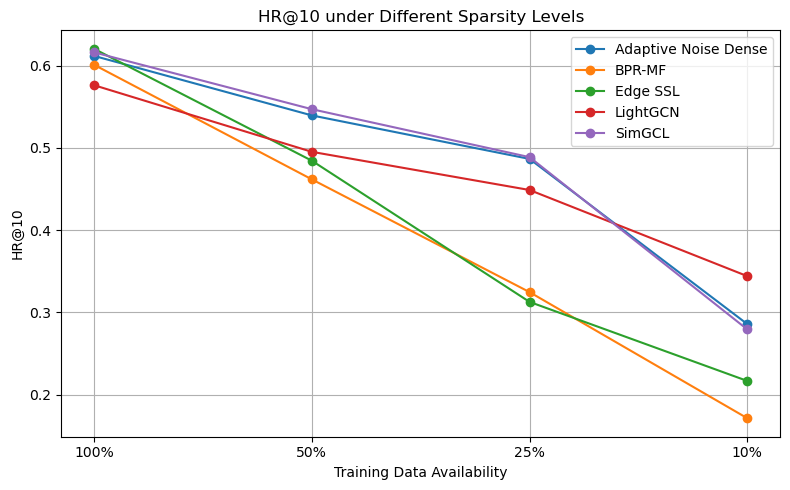

In [69]:
# HR Sparsity Plot

import matplotlib.pyplot as plt

order = ["100%", "50%", "25%", "10%"]
sparsity_pivot_hr = sparsity_pivot_hr.reindex(order)

plt.figure(figsize=(8,5))

for method in sparsity_pivot_hr.columns:
    plt.plot(
        sparsity_pivot_hr.index,
        sparsity_pivot_hr[method],
        marker="o",
        label=method
    )

plt.ylabel("HR@10")
plt.xlabel("Training Data Availability")
plt.title("HR@10 under Different Sparsity Levels")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "sparsity_hr10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

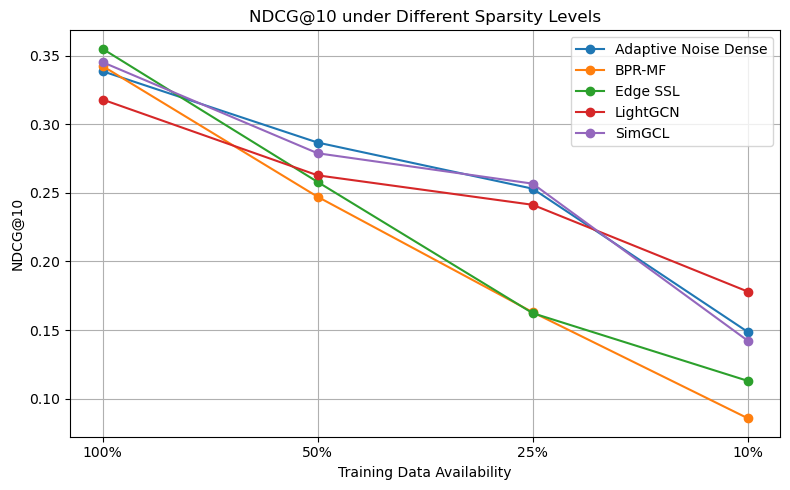

In [70]:
# NDCG sparsity plot

order = ["100%", "50%", "25%", "10%"]
sparsity_pivot_ndcg = sparsity_pivot_ndcg.reindex(order)

plt.figure(figsize=(8,5))

for method in sparsity_pivot_ndcg.columns:
    plt.plot(
        sparsity_pivot_ndcg.index,
        sparsity_pivot_ndcg[method],
        marker="o",
        label=method
    )

plt.ylabel("NDCG@10")
plt.xlabel("Training Data Availability")
plt.title("NDCG@10 under Different Sparsity Levels")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "sparsity_ndcg10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# THE END!